# 📌 Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 Load Dataset

In [2]:
df = pd.read_csv('../data/raw/restaurant_orders.csv')
df.head()

,Order ID,Customer Name,Food Item,Category,Quantity,Price,Payment Method,Order Time
0,2268,Mary Vega DDS,Pasta,Main,5,16.52,Cash,2025-02-02 14:28:41
1,3082,Brandon Myers,Brownie,Dessert,4,17.27,Debit Card,2025-06-08 10:57:47
2,3160,Margaret Wells,Pasta,Main,1,3.37,Credit Card,2025-03-04 07:41:41
3,1272,Michael Matthews,Pasta,Main,5,2.20,Online Payment,2025-05-15 12:43:45
4,9447,Connor Williams,Soup,Starter,1,12.23,Cash,2025-03-15 14:25:56


# 📌 Basic Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        500 non-null    int64  
 1   Customer Name   500 non-null    object 
 2   Food Item       500 non-null    object 
 3   Category        500 non-null    object 
 4   Quantity        500 non-null    int64  
 5   Price           500 non-null    float64
 6   Payment Method  500 non-null    object 
 7   Order Time      500 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 31.4+ KB


In [4]:
df.describe()

,Order ID,Quantity,Price
count,500.000000,500.000000,500.000000
mean,5683.296000,3.030000,13.197180
std,2599.688068,1.474261,6.685852
min,1055.000000,1.000000,2.060000
25%,3342.000000,2.000000,7.280000
50%,5762.000000,3.000000,13.305000
75%,7945.000000,4.000000,19.080000
max,9997.000000,5.000000,24.990000


In [5]:
df.isnull().sum()

Order ID          0
Customer Name     0
Food Item         0
Category          0
Quantity          0
Price             0
Payment Method    0
Order Time        0
dtype: int64

# 📌 Revenue feature

In [6]:
df['Revenue'] = df['Quantity'] * df['Price']

# 📌 Distribution Plot

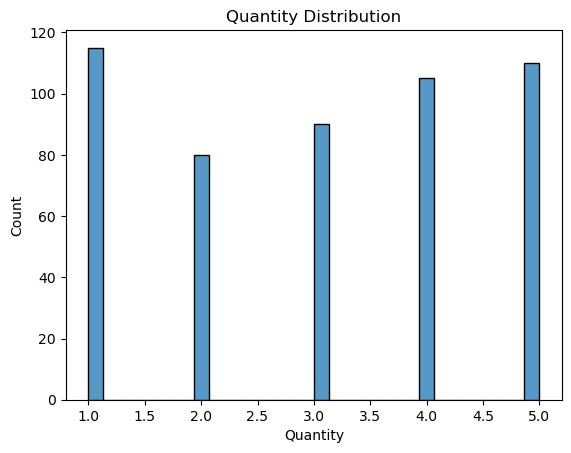

In [7]:
sns.histplot(df['Quantity'], bins=30)
plt.title("Quantity Distribution")
plt.show()

# 📌 Category-wise Sales

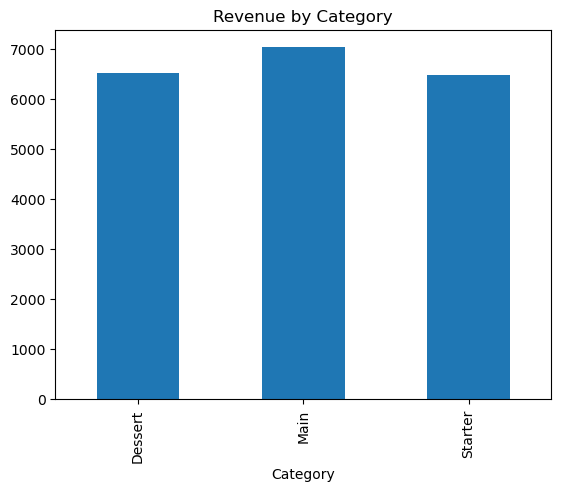

In [8]:
category_sales = df.groupby('Category')['Revenue'].sum()
category_sales.plot(kind='bar')
plt.title("Revenue by Category")
plt.show()

# 📌 Payment Method Pie Chart

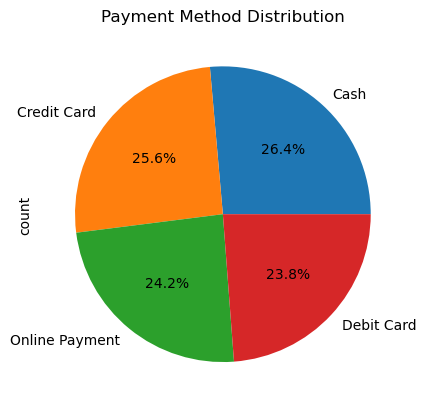

In [9]:
df['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()

# 📌 Hourly Orders

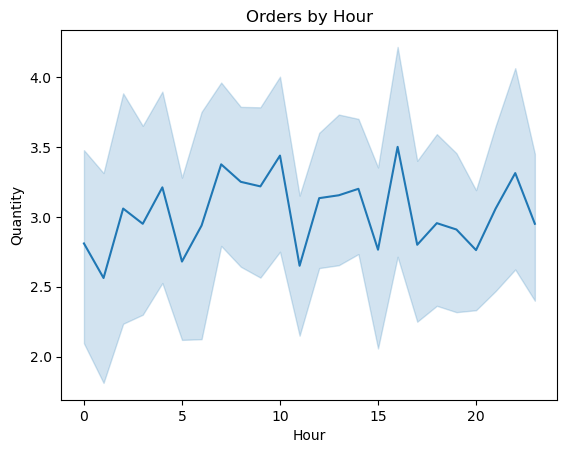

In [10]:
df['Order Time'] = pd.to_datetime(df['Order Time'])
df['Hour'] = df['Order Time'].dt.hour

sns.lineplot(x='Hour', y='Quantity', data=df)
plt.title("Orders by Hour")
plt.show()